In [1]:
# All the imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [2]:
# Loading the dataset

df = pd.read_csv("../data/job_market.csv")
df.head()

# Basic information on the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_title            250 non-null    str    
 1   company              250 non-null    str    
 2   location             250 non-null    str    
 3   job_type             221 non-null    str    
 4   category             230 non-null    str    
 5   salary_min           250 non-null    int64  
 6   salary_max           250 non-null    int64  
 7   experience_required  207 non-null    float64
 8   publication_date     250 non-null    str    
 9   skills               200 non-null    str    
 10  education_level      250 non-null    str    
 11  company_size         250 non-null    str    
 12  benefits             250 non-null    str    
dtypes: float64(1), int64(2), str(10)
memory usage: 25.5 KB


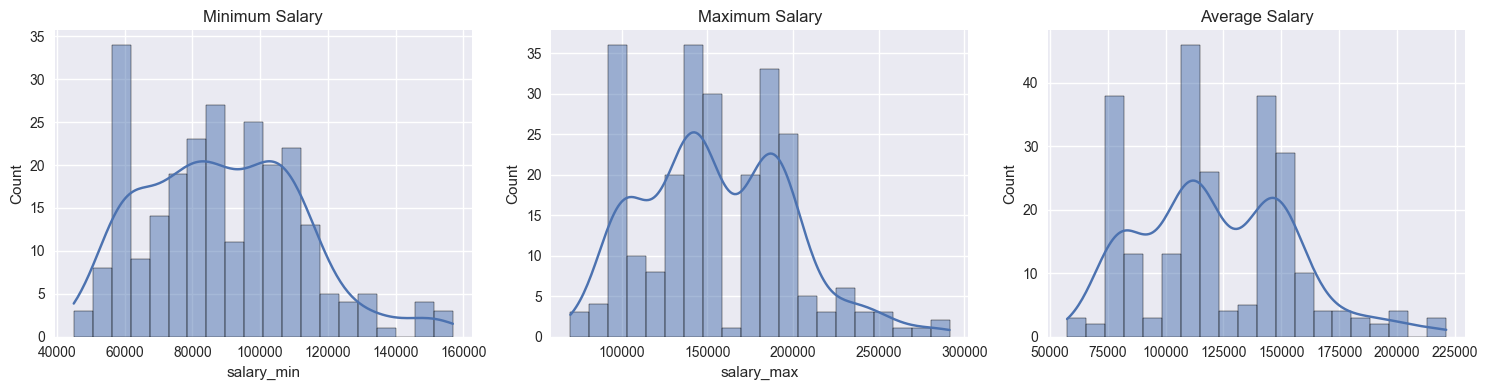

In [ ]:
# Plotting the Salary Distribution for minimum, maximum, and the average salaries

fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(df["salary_min"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Minimum Salary")

sns.histplot(df["salary_max"], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Maximum Salary")

salary_avg = (df["salary_min"] + df["salary_max"]) / 2
sns.histplot(salary_avg, bins=20, kde=True, ax=axes[2])
axes[2].set_title("Average Salary")

plt.tight_layout()
plt.show()


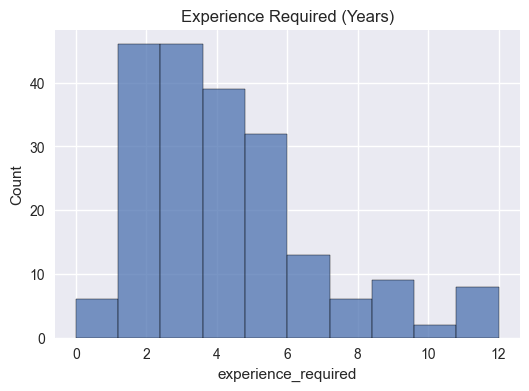

In [4]:
# Plotting the distributions for the number of years of experience required.

plt.figure(figsize=(6,4))
sns.histplot(df["experience_required"], bins=10, kde=False)
plt.title("Experience Required (Years)")
plt.show()

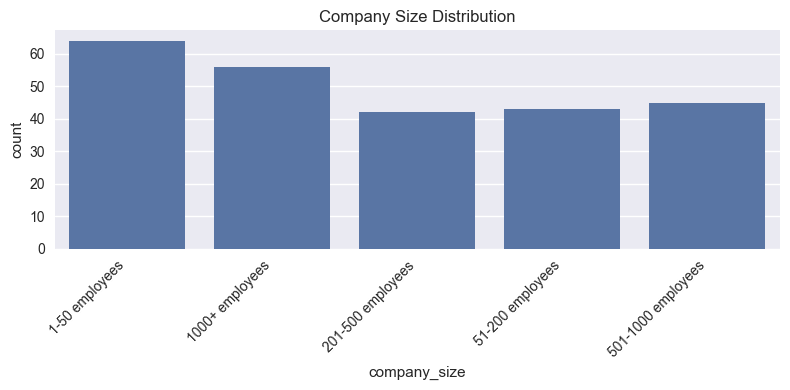

In [5]:
# Plotting the distributions for the company size.

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="company_size")
plt.xticks(rotation=45, ha="right")
plt.title("Company Size Distribution")
plt.tight_layout()
plt.show()

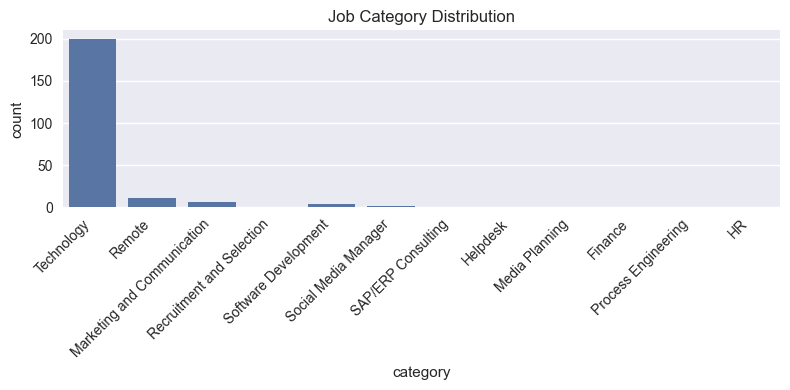

In [8]:
# Plotting the job category distribution

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="category")
plt.xticks(rotation=45, ha="right")
plt.title("Job Category Distribution")
plt.tight_layout()
plt.show()

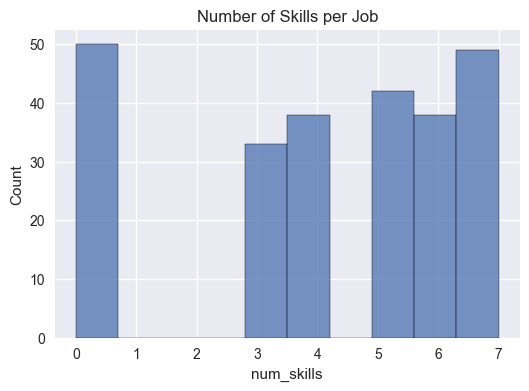

In [9]:
# Counting and plotting the number of skills 
def count_skills(s):
    if isinstance(s, str):
        return len([x.strip() for x in s.split(",")])
    return 0

df["num_skills"] = df["skills"].apply(count_skills)

plt.figure(figsize=(6,4))
sns.histplot(df["num_skills"], bins=10, kde=False)
plt.title("Number of Skills per Job")
plt.show()

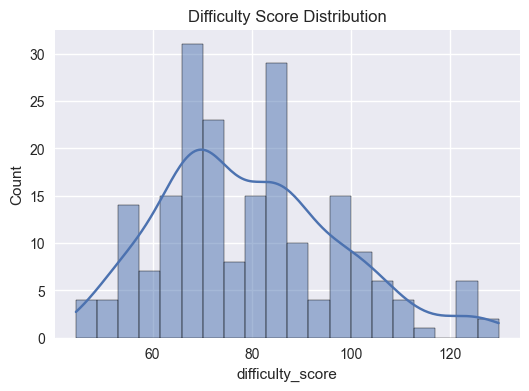

In [10]:
# Plotting the difficulty scores for the job posting
df["salary_avg"] = (df["salary_min"] + df["salary_max"]) / 2

size_map = {
    "1-50 employees": 0,
    "51-200 employees": 1,
    "201-500 employees": 2,
    "500+ employees": 3
}

df["company_size_clean"] = df["company_size"].fillna("Unknown")

df["difficulty_score"] = (
    1.2 * df["num_skills"]
    + 2.0 * df["experience_required"]
    + 0.0005 * df["salary_avg"]
    + df["company_size_clean"].map(size_map).fillna(1)
)

plt.figure(figsize=(6,4))
sns.histplot(df["difficulty_score"], bins=20, kde=True)
plt.title("Difficulty Score Distribution")
plt.show()